MACHINE LEARNING PROJECT : CARDIOVASCULAR DISEASE

NUR AIN SYAFIQAH BINTI NOR AZLAN (CI230153)
<br>NUR SYAHINDAH AFIQAH BINTI YUSAIDI (CI230152)</br>
UTHMAN BIN HASFIZAL (CI230068)
<br>SYED MOHAMAD ZHARFAN BIN SYED MOHD ROBART (AI230268)

DATASET : https://www.kaggle.com/datasets/sulianova/cardiovascular-disease-dataset/data\

**CARDIOVASCULAR DISEASE**

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

Data Preprocessing

In [ ]:
df = pd.read_csv('cardio_train.csv', sep =';')
df.head()

,id,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
0,0,18393,2,168,62.0,110,80,1,1,0,0,1,0
1,1,20228,1,156,85.0,140,90,3,1,0,0,1,1
2,2,18857,1,165,64.0,130,70,3,1,0,0,0,1
3,3,17623,2,169,82.0,150,100,1,1,0,0,1,1
4,4,17474,1,156,56.0,100,60,1,1,0,0,0,0


In [ ]:
df.info()
print(df.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 70000 entries, 0 to 69999
Data columns (total 13 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   id           70000 non-null  int64  
 1   age          70000 non-null  int64  
 2   gender       70000 non-null  int64  
 3   height       70000 non-null  int64  
 4   weight       70000 non-null  float64
 5   ap_hi        70000 non-null  int64  
 6   ap_lo        70000 non-null  int64  
 7   cholesterol  70000 non-null  int64  
 8   gluc         70000 non-null  int64  
 9   smoke        70000 non-null  int64  
 10  alco         70000 non-null  int64  
 11  active       70000 non-null  int64  
 12  cardio       70000 non-null  int64  
dtypes: float64(1), int64(12)
memory usage: 6.9 MB
id             0
age            0
gender         0
height         0
weight         0
ap_hi          0
ap_lo          0
cholesterol    0
gluc           0
smoke          0
alco           0
active         0
cardio

A preliminary assessment of the dataset revealed zero missing values, negating the need for imputation techniques. However the dataset contained significant noise and outliers.

In [ ]:
min_bp = df['ap_hi'].min()
max_bp = df['ap_hi'].max()

In [ ]:
print(f"Lowest Systolic BP: {min_bp}")
print(f"Highest Systolic BP: {max_bp}")

Lowest Systolic BP: -150
Highest Systolic BP: 16020


This shows that the datasets is raw where the minimum systolic blood pressure is -150 and the highest is 16020 where it is impossible for human.

Systolic : below 50 means dead or coma
Dystolic : above 250 means hypertensive

In [ ]:
#Data cleaning
#1. remove negative or impossible pressures
df_clean = df[(df['ap_hi'] >= 50) & (df['ap_hi'] <=250)]
df_clean = df_clean[(df_clean['ap_lo'] >= 30) & (df_clean['ap_lo'] <=150)]

#2. remove "impossible" physics
#dystolic (lower number) cannot be higher than systolic (higher number)
df_clean = df_clean[df_clean['ap_hi'] > df_clean['ap_lo']]

print(f"Cleaned Row Count : {len(df_clean)}")
print(f"Rows Removed: {len(df) - len(df_clean)}")


Cleaned Row Count : 68673
Rows Removed: 1327


In [ ]:
#Verify the cleaning
print("/n--- New stats After Cleaning ---")
print(f"Max Systolic : {df_clean['ap_hi'].max()}")
print(f"Min Systolic : {df_clean['ap_hi'].min()}")

/n--- New stats After Cleaning ---
Max Systolic : 240
Min Systolic : 60


**Chart 1 : Before Cleaning & After Cleaning Data**

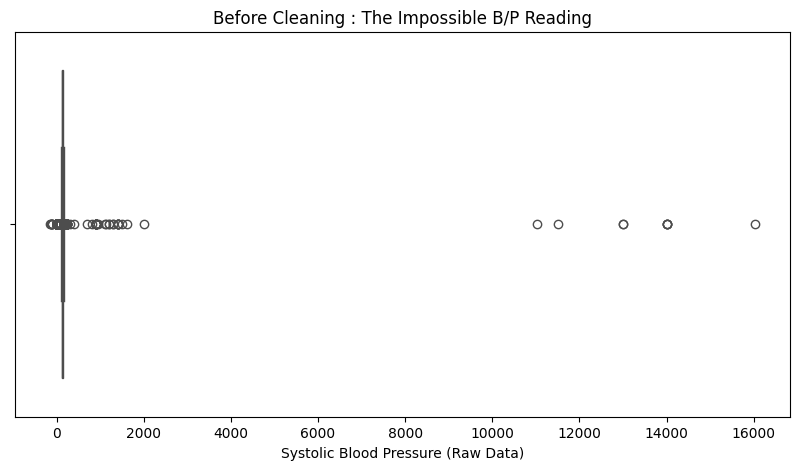

In [ ]:
#Scatter plot for before data cleaning

plt.figure(figsize=(10,5))

sns.boxplot(x = df['ap_hi'], color='red')
plt.title('Before Cleaning : The Impossible B/P Reading')
plt.xlabel('Systolic Blood Pressure (Raw Data)')


plt.show()

This shows that the outliers of the data is so big to 16,000. Therefore, we create a side by side graph to demonstrates the zoomed out and zoomed in graphs.

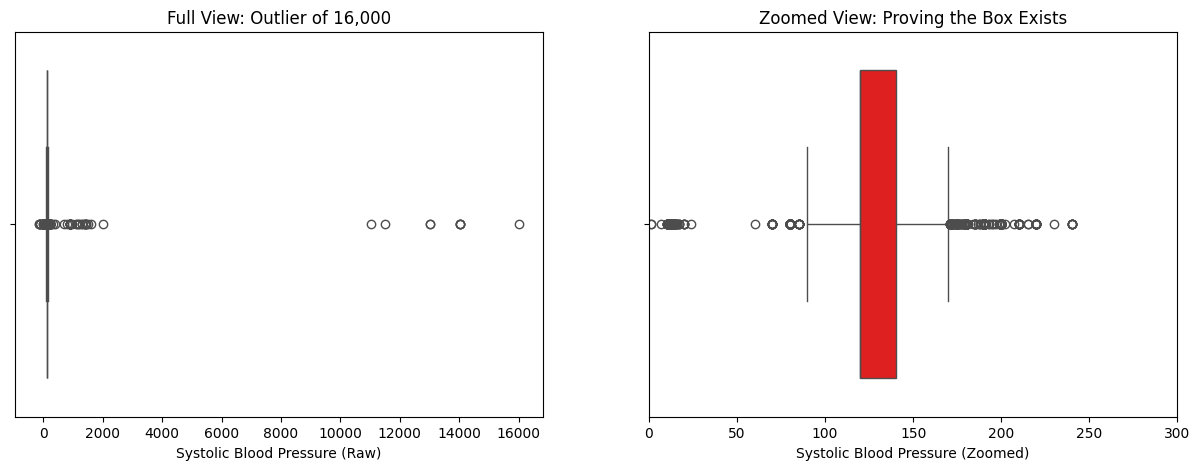

In [ ]:
# charts side-by-side
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# CHART 1: THE FULL VIEW (Shows the errors (raw data))
sns.boxplot(x=df['ap_hi'], ax=axes[0], color='red')
axes[0].set_title('Full View: Outlier of 16,000')
axes[0].set_xlabel('Systolic Blood Pressure (Raw)')

# CHART 2: THE ZOOMED VIEW
# We force the graph to ignore the 16,000
sns.boxplot(x=df['ap_hi'], ax=axes[1], color='red')
axes[1].set_xlim(0, 300) # zoomed in the graphs
axes[1].set_title('Zoomed View: Proving the Box Exists')
axes[1].set_xlabel('Systolic Blood Pressure (Zoomed)')

plt.show()

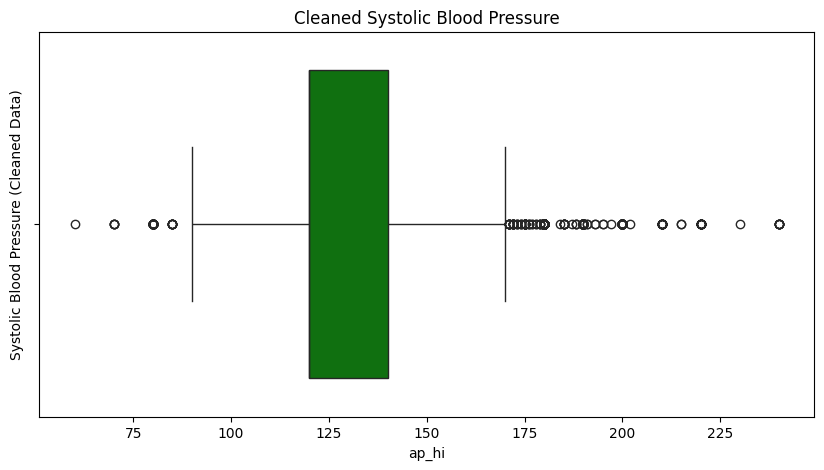

In [ ]:
plt.figure(figsize=(10,5))

sns.boxplot(x = df_clean['ap_hi'], color='green')
plt.title('Cleaned Systolic Blood Pressure')
plt.ylabel('Systolic Blood Pressure (Cleaned Data)')


plt.show()

In [ ]:
# Kira nilai Q1 dan Q3
q1 = df_clean['ap_hi'].quantile(0.25)
q3 = df_clean['ap_hi'].quantile(0.75)
iqr = q3 - q1

print(f"Q1: {q1}")
print(f"Q3: {q3}")
print(f"IQR: {iqr}")

median_val = df_clean['ap_hi'].median()
print(f"Median Value of Blood Pressure : {median_val}")

Q1: 120.0
Q3: 140.0
IQR: 20.0
Median Value of Blood Pressure : 120.0


In [ ]:
# Kira berapa ramai orang yang ada bacaan 120
totalPeople_120 = df_clean[df_clean['ap_hi'] == 120].shape[0]
total_people = df_clean.shape[0]
percent = (totalPeople_120 / total_people) * 100

print(f"People with BP 120: {totalPeople_120}")
print(f"Overall Percentage: {percent:.2f}%")

# Tengok nilai Q1, Median, Q3
print(df_clean['ap_hi'].describe())

People with BP 120: 27664
Overall Percentage: 40.28%
count    68673.000000
mean       126.668997
std         16.682602
min         60.000000
25%        120.000000
50%        120.000000
75%        140.000000
max        240.000000
Name: ap_hi, dtype: float64


<h5>The conclusion we could received from the boxplot analysis reveals that the Interquatile Range (IQR) representing the middle 50%of the population spans from 120 mmHg(Q1) to 140mmHg(Q3). In medical term, this is significant because a systolic reading above 130 mmHg is classified as Stage 1 Hypertension. This suggests that the majority of the dataset consists of individuals who are already at risk or suffering from mild to moderate hypertension. </h5>



<h5> The whiskers of the plot indicate an effective data range of 80 mmHg to approximately 174 mmHg. While in statistical labels, any data point is above 174 mmHg as an outlier. In the medical domain, these values represent patients in a hypertensive crisis. Therefore, our model must remain sensitive to these extreme values rather than discarding them as mere noise and as representing the highest-risk group./h5>

**Feature Engineering**

<h6>Identify the patients who can be classified as hypertension and hypotension</h6>

In [ ]:
# Create BMI (Body Mass Index)
# BMI = Weight (kg) / Height

df_clean['BMI'] = df_clean['weight']/((df_clean['height']/100) ** 2)


**Relationships Between BMI and Heart Disease**

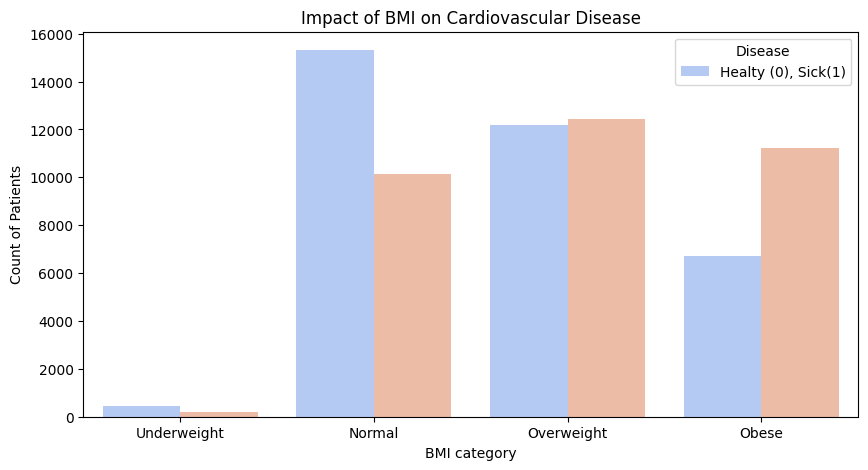

In [ ]:
plt.figure (figsize = (10, 5))

df_clean['BMI_class'] = pd.cut(df_clean['BMI'],
                               bins =[0, 18.5, 25, 30, 100],
                               labels = ['Underweight', 'Normal','Overweight', 'Obese'])

#Count which BMI class have Heart Disease
sns.countplot(x = 'BMI_class', hue ='cardio', data = df_clean, palette ='coolwarm')

plt.title('Impact of BMI on Cardiovascular Disease')
plt.xlabel('BMI category')
plt.ylabel('Count of Patients')
plt.legend(title = 'Disease', labels =['Healty (0), Sick(1)'])
plt.show()

This conclude that BMI has impact on the cardiovascular disease where most of the **obese patients** are most likely to get heart disease compared to those who have normal and underweight.

**Relationships between Age Group and Heart Disease**

Categorize the age : <br>
**Young Adult** < 45 <br>
**Middle Aged** < 60 <br>
**Senior** > 60

In [ ]:
df_clean['age_years'] = (df_clean['age']/365).round(0) # round 1 meaning that we want only 1 decimal point

def categorize_age(age):
  if age < 45:
    return 'Young Adult'
  elif age < 60:
      return 'Middle Aged'
  else:
      return 'Senior'

# apply it to dataframe
df_clean['age_group'] = df_clean['age_years'].apply(categorize_age)

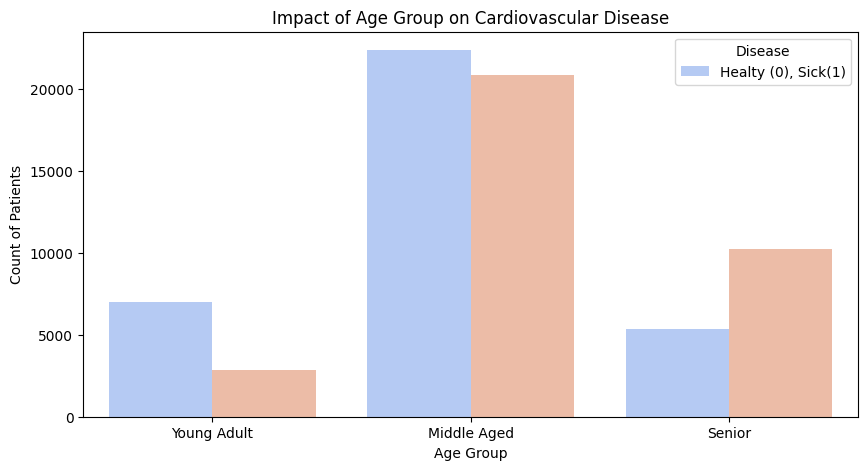

In [ ]:
plt.figure (figsize = (10, 5))

#Count which age group class have Heart Disease
sns.countplot(x = 'age_group', hue ='cardio', data = df_clean,
              order = ['Young Adult', 'Middle Aged', 'Senior'],
              palette ='coolwarm')

plt.title('Impact of Age Group on Cardiovascular Disease')
plt.xlabel('Age Group')
plt.ylabel('Count of Patients')
plt.legend(title = 'Disease', labels =['Healty (0), Sick(1)'])
plt.show()

In this findings, shows that most of the heart disease patients are more likely comes from middle aged group.

**Relationship between Pulse Pressure and Heart Disease**

In [ ]:
#Pulse Pressure
# Systolic - Diastolic
df_clean['pulse_pressure'] = df_clean['ap_hi'] - df_clean['ap_lo']

/tmp/ipython-input-2645470256.py:4: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(df_clean[df_clean['cardio'] == 0]['pulse_pressure'],
/tmp/ipython-input-2645470256.py:8: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(df_clean[df_clean['cardio'] == 1]['pulse_pressure'],


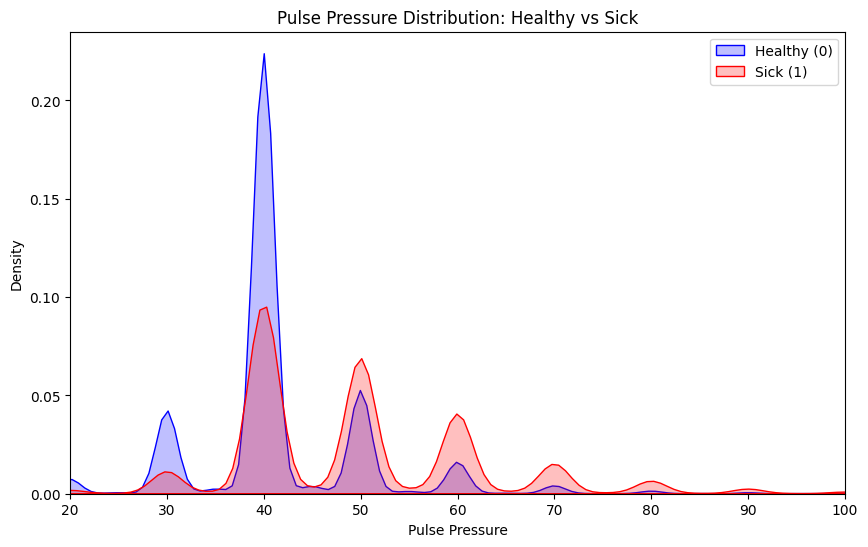

In [ ]:
plt.figure(figsize=(10, 6))

# Lukis "Bukit" untuk Orang Sihat (Biru)
sns.kdeplot(df_clean[df_clean['cardio'] == 0]['pulse_pressure'],
            label='Healthy (0)', shade=True, color='blue')

# Lukis "Bukit" untuk Orang Sakit (Merah)
sns.kdeplot(df_clean[df_clean['cardio'] == 1]['pulse_pressure'],
            label='Sick (1)', shade=True, color='red')

plt.title('Pulse Pressure Distribution: Healthy vs Sick')
plt.xlabel('Pulse Pressure')
plt.xlim(20, 100) # Fokus pada kawasan utama
plt.legend()
plt.show()

According to medical data, a normal pulse pressure (arteria stiffness)(systolic - diastolic) should be around 40 mmHg which illustrated through the Histogram graph where most of healthy patient's pulse pressure is 40 mmHg and the distribution shifted to red (sick) to the right-side of the graph.

Conclude that higher pulse pressure = higher risk of heart disease.

**HEATMAP CORRELATION**

To ensure the ap_hi and the pulse pressure is not too same before proceed to train the model

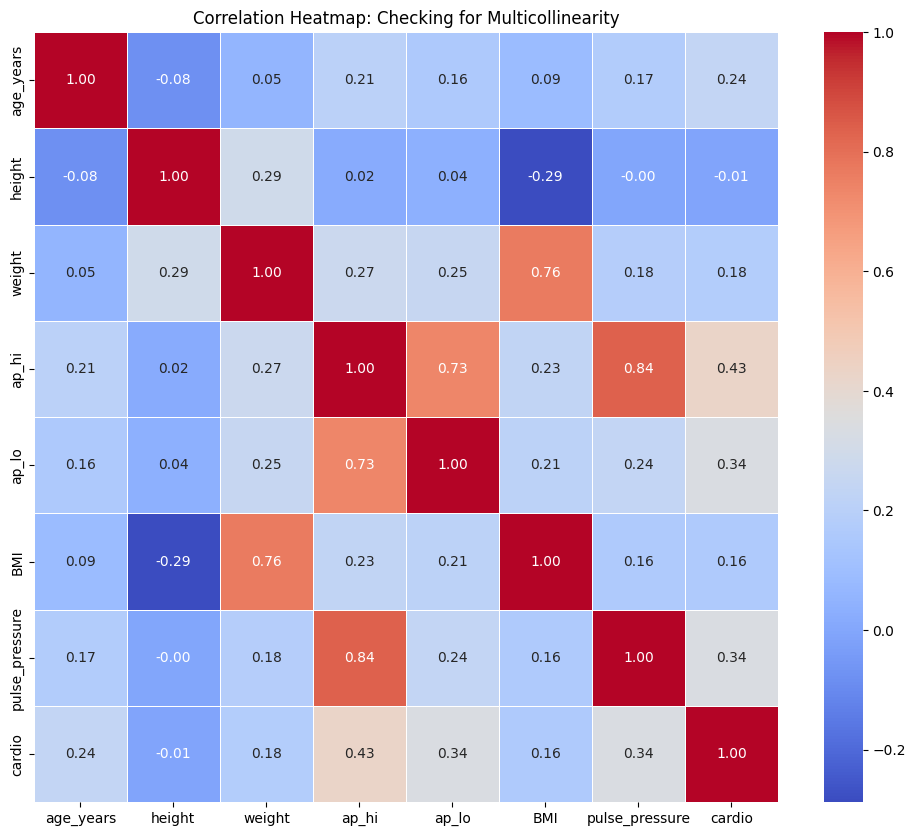

In [ ]:
plt.figure(figsize=(12, 10))

# Select numerical columns only
cols_to_check = ['age_years', 'height', 'weight', 'ap_hi', 'ap_lo', 'BMI', 'pulse_pressure', 'cardio']
corr_matrix = df_clean[cols_to_check].corr()

# Draw the Heatmap
# annot=True (Writes the numbers in the boxes)
# fmt='.2f' (2 decimal places)
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', linewidths=0.5)

plt.title('Correlation Heatmap: Checking for Multicollinearity')
plt.show()

**Final Pre-Processing**

In [ ]:
from sklearn.model_selection import train_test_split

In [ ]:
# remove redundant column
df_clean.head()

,id,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio,BMI,BMI_class,age_years,age_group,pulse_pressure
0,0,18393,2,168,62.0,110,80,1,1,0,0,1,0,21.967120,Normal,50.0,Middle Aged,30
1,1,20228,1,156,85.0,140,90,3,1,0,0,1,1,34.927679,Obese,55.0,Middle Aged,50
2,2,18857,1,165,64.0,130,70,3,1,0,0,0,1,23.507805,Normal,52.0,Middle Aged,60
3,3,17623,2,169,82.0,150,100,1,1,0,0,1,1,28.710479,Overweight,48.0,Middle Aged,50
4,4,17474,1,156,56.0,100,60,1,1,0,0,0,0,23.011177,Normal,48.0,Middle Aged,40


In [ ]:
df_model = df_clean.drop(columns = ['id', 'age', 'age_group','BMI_class', 'pulse_pressure'], errors = 'ignore')
df_model.head()

,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio,BMI,age_years
0,2,168,62.0,110,80,1,1,0,0,1,0,21.967120,50.0
1,1,156,85.0,140,90,3,1,0,0,1,1,34.927679,55.0
2,1,165,64.0,130,70,3,1,0,0,0,1,23.507805,52.0
3,2,169,82.0,150,100,1,1,0,0,1,1,28.710479,48.0
4,1,156,56.0,100,60,1,1,0,0,0,0,23.011177,48.0


In [ ]:
# determine the X input
# all except cardio
X = df_model.drop(columns = 'cardio')

# Y output
y = df_model['cardio']

In [ ]:
# split the data 80% for training and 20% for testing
X_train, X_testing, y_train, y_testing = train_test_split(X,y, test_size = 0.2, random_state = 42)

# Patient for Training
print(f"Total patients for training : {len(X_train)}")

# Patient for Testing
print(f"Total patients for testing : {len(X_testing)}")

#Final column for model
print(f"Final column for model : {X.columns.tolist()}")

Total patients for training : 54938
Total patients for testing : 13735
Final column for model : ['gender', 'height', 'weight', 'ap_hi', 'ap_lo', 'cholesterol', 'gluc', 'smoke', 'alco', 'active', 'BMI', 'age_years']


**Random Forest Classifier**

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score

In [ ]:
# develop model
rf_model = RandomForestClassifier(n_estimators = 100, random_state = 42)

# train the model
rf_model.fit(X_train, y_train)

#making prediction
y_pred = rf_model.predict(X_testing)

In [ ]:
# accuracy score for train model

accuracy = accuracy_score(y_testing, y_pred)
print(f"Accuracy: {accuracy*100:.2f}%")

Accuracy: 70.63%


In [ ]:
#f1_score
RF_f1 = f1_score(y_testing, rf_model.predict(X_testing))
print(f"F1 Score: {RF_f1*100:.2f}%")

F1 Score: 69.85%


**Confusion Matrix for Model Prediction**

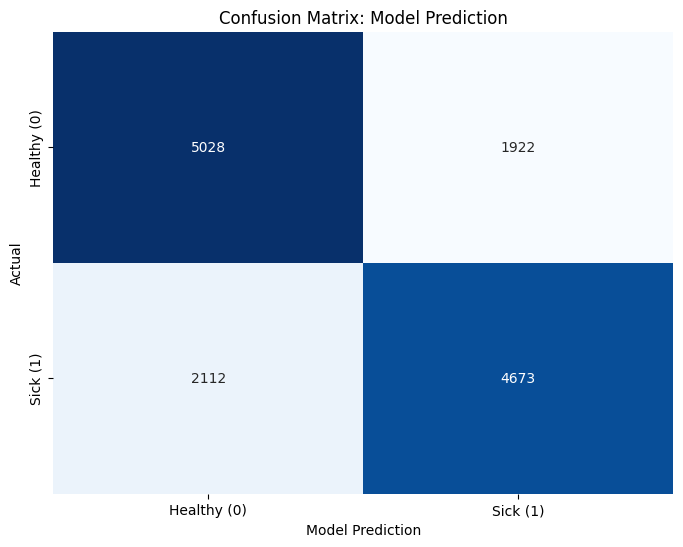

In [ ]:
plt.figure(figsize=(8, 6))
confusion_M = confusion_matrix(y_testing, y_pred)

sns.heatmap(confusion_M, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title('Confusion Matrix: Model Prediction')
plt.xlabel('Model Prediction')
plt.ylabel('Actual')
plt.xticks([0.5, 1.5], ['Healthy (0)', 'Sick (1)'])
plt.yticks([0.5, 1.5], ['Healthy (0)', 'Sick (1)'])
plt.show()

In [ ]:
print("Classifiction Report")
print(classification_report(y_testing, y_pred))

Classifiction Report
              precision    recall  f1-score   support

           0       0.70      0.72      0.71      6950
           1       0.71      0.69      0.70      6785

    accuracy                           0.71     13735
   macro avg       0.71      0.71      0.71     13735
weighted avg       0.71      0.71      0.71     13735



**Feature Importance**


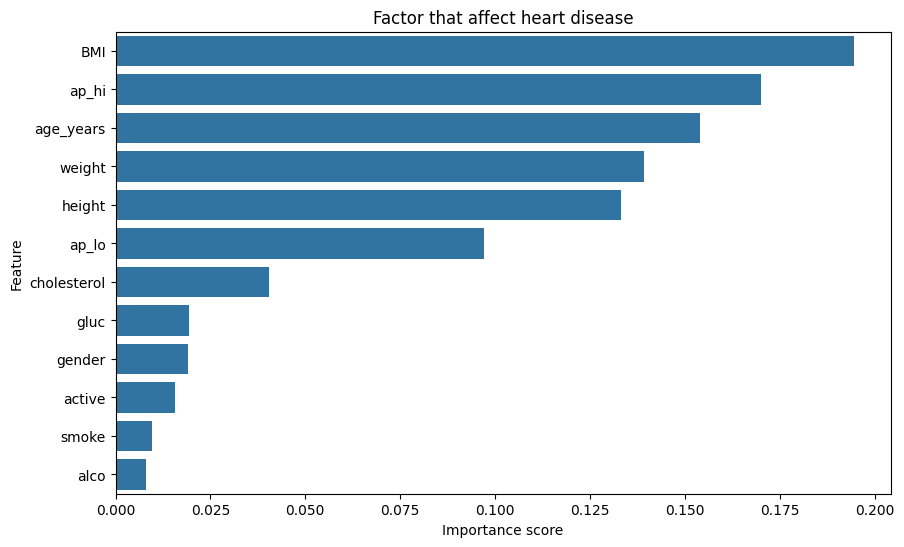

Feature Importance:
        Feature  Importance
10          BMI    0.194464
3         ap_hi    0.169932
11    age_years    0.153891
2        weight    0.139120
1        height    0.133181
4         ap_lo    0.096974
5   cholesterol    0.040385
6          gluc    0.019436
0        gender    0.019110
9        active    0.015668
7         smoke    0.009740
8          alco    0.008100


In [ ]:
# get importance count from each column
importances_graph = rf_model.feature_importances_
feature_names = X.columns

#input in dataframe for clean look
feature_importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances_graph
})

#arrange from most important to less important
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)

# Plot the feature importance
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df)
plt.title('Factor that affect heart disease')
plt.xlabel('Importance score')
plt.ylabel('Feature')
plt.show()

print("Feature Importance:")
print(feature_importance_df)

**Findings on why BMI is the Important Feature**

The graph clearly identifies BMI is the most important factor for predicting heart disease followed by higher blood pressure (ap_hi). this means the model focuses on a person's body weight and their top blood pressure number when deciding risk. In general, **higher BMI and higher blood pressure lead to a higher chance of heart disease** in the model.

However the observations does mean these two factors decide everything. Sometimes, a person with low blood pressure can still be sick and a person with high blood pressure can be healthy. This happens because the model look at all features together not just one.

Example : Someone with low blood pressure might still be at risk because they older, have high cholesterol or do not exercise. On other hand, a younger person with high blood pressure might still be seen healthy if they have a low BMI, do not smoke and physically active.

So, BMI and blood pressure are very important but **heart disease risk depends on many factors working together.**

**Model Testing**

In [ ]:

def Heart(age, gender, height, weight, ap_hi, ap_lo, cholesterol, gluc, smoke, alco, active):

    # 1. AUTO-CALCULATE FEATURE
    bmi_real = weight / ((height / 100) ** 2)
    pulse_pressure_real = ap_hi - ap_lo

    # 2. Masukkan dalam Dictionary
    input_data = {
        'age_years': age,
        'gender': gender,
        'ap_hi': ap_hi,
        'ap_lo': ap_lo,
        'cholesterol': cholesterol,
        'gluc': gluc,
        'smoke': smoke,
        'alco': alco,
        'active': active,
        'BMI': bmi_real,
        'pulse_pressure': pulse_pressure_real
    }

    # 3. Convert ke DataFrame
    df_input = pd.DataFrame([input_data])

    df_final = df_input.reindex(columns=X.columns, fill_value=0)

    # 5. Predict
    prediction = rf_model.predict(df_final)[0]
    probability = rf_model.predict_proba(df_final)[0]

    # 6. Papar Keputusan (Dengan Logic yang DIBETULKAN)
    print("\n" + "="*30)
    print(f"📊 Patient (Age: {age}, BMI: {bmi_real:.1f})")
    print("="*30)

    if prediction == 1:
        prob_sick = probability[1] * 100
        print(f"Patient is concluded to have Heart Disease")
        print(f"Model Accuracy: {prob_sick:.1f}%")
        print(f"Primary Factor: Tekanan Darah {ap_hi}/{ap_lo} & Pulse Pressure {pulse_pressure_real}")
    else:
        prob_healthy = probability[0] * 100
        print(f"Patient is healthy and low risk to have Heart Disease")
        print(f"🛡️ Model Accuracy: {prob_healthy:.1f}%")

# input new patient data
Heart(
    age=50,
    gender=2,
    height=168,
    weight=62.0,
    ap_hi=153,
    ap_lo=120,
    cholesterol=1,
    gluc=2,
    smoke=1,
    alco=0,
    active=1
)


📊 Patient (Age: 50, BMI: 22.0)
Patient is concluded to have Heart Disease
Model Accuracy: 73.0%
Primary Factor: Tekanan Darah 153/120 & Pulse Pressure 33


**Decision Tree Model (Model Winner)**

In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, f1_score, recall_score

In [ ]:
# prevent from overfitting model
decision_T = DecisionTreeClassifier(max_depth =10, random_state = 42)

In [ ]:
#training model decision tree
decision_T.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=10, random_state=42)

In [ ]:
# Decision Tree Performance

decision_T_train_accuracy = accuracy_score(y_train, decision_T.predict(X_train))
decision_T_test_accuraccy = accuracy_score(y_testing, decision_T.predict(X_testing))

dT_f1 = f1_score(y_testing, decision_T.predict(X_testing))

In [ ]:
print(f"Decision Tree Training Accuracy: {decision_T_train_accuracy*100:.2f}%")
print(f"Decision Tree Testing Accuracy: {decision_T_test_accuraccy*100:.2f}%")

Decision Tree Training Accuracy: 75.14%
Decision Tree Testing Accuracy: 72.46%


In [ ]:
#f1_score
print(f"F1 Score: {dT_f1*100:.2f}%")

F1 Score: 71.18%


TypeError: 'str' object is not callable

<Figure size 1000x600 with 0 Axes>

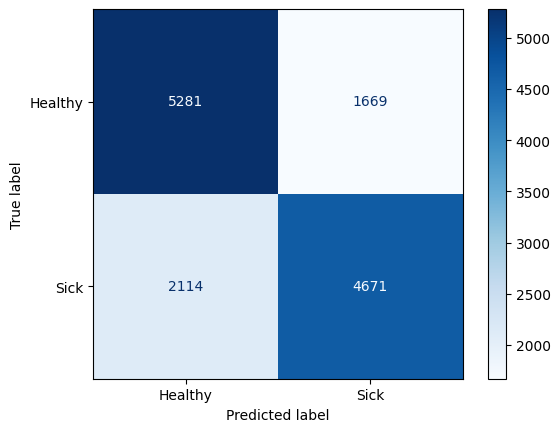

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

plt.figure(figsize=(10, 6))

ConfusionMatrixDisplay.from_estimator(
    decision_T,               # Model Juara Awak
    X_testing,
    y_testing,
    display_labels=['Healthy', 'Sick'],
    cmap='Blues',
    values_format='d'
)

plt.title('Confusion Matrix: Decision Tree (Winner Model)')
plt.grid(False)
plt.show()

**Feature Importance**

/tmp/ipython-input-2320455039.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=feature_importance_DT, palette = 'magma')


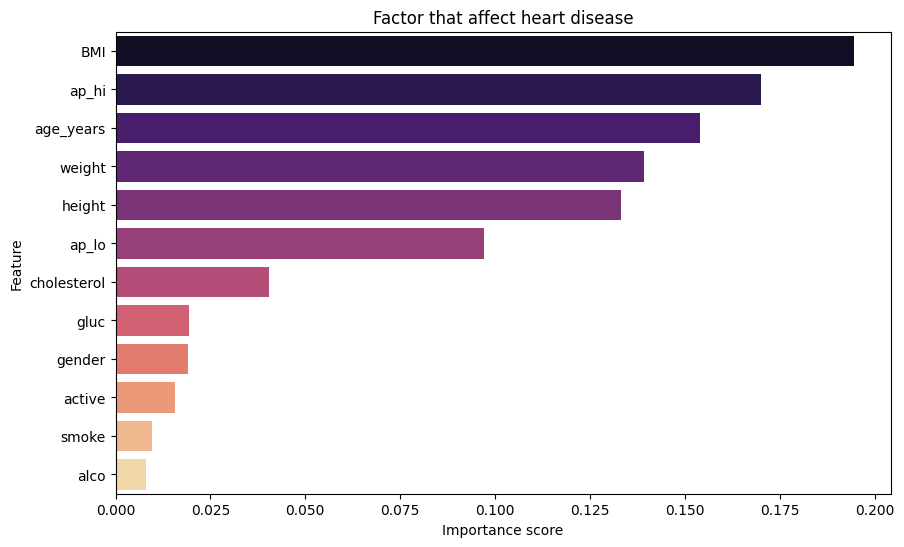

Feature Importance:
        Feature  Importance
10          BMI    0.194464
3         ap_hi    0.169932
11    age_years    0.153891
2        weight    0.139120
1        height    0.133181
4         ap_lo    0.096974
5   cholesterol    0.040385
6          gluc    0.019436
0        gender    0.019110
9        active    0.015668
7         smoke    0.009740
8          alco    0.008100


In [ ]:
# get importance count from each column
DT_importances_graph = decision_T.feature_importances_
feature_names = X.columns

#input in dataframe for clean look
feature_importance_DT = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances_graph
})

#arrange from most important to less important
feature_importance_DT = feature_importance_DT.sort_values(by='Importance', ascending=False)

# Plot the feature importance
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feature_importance_DT, palette = 'magma')
plt.title('Factor that affect heart disease')
plt.xlabel('Importance score')
plt.ylabel('Feature')
plt.show()

print("Feature Importance:")
print(feature_importance_DT)

**Decision Tree Plot**

In [ ]:
from sklearn.tree import plot_tree

TypeError: 'str' object is not callable

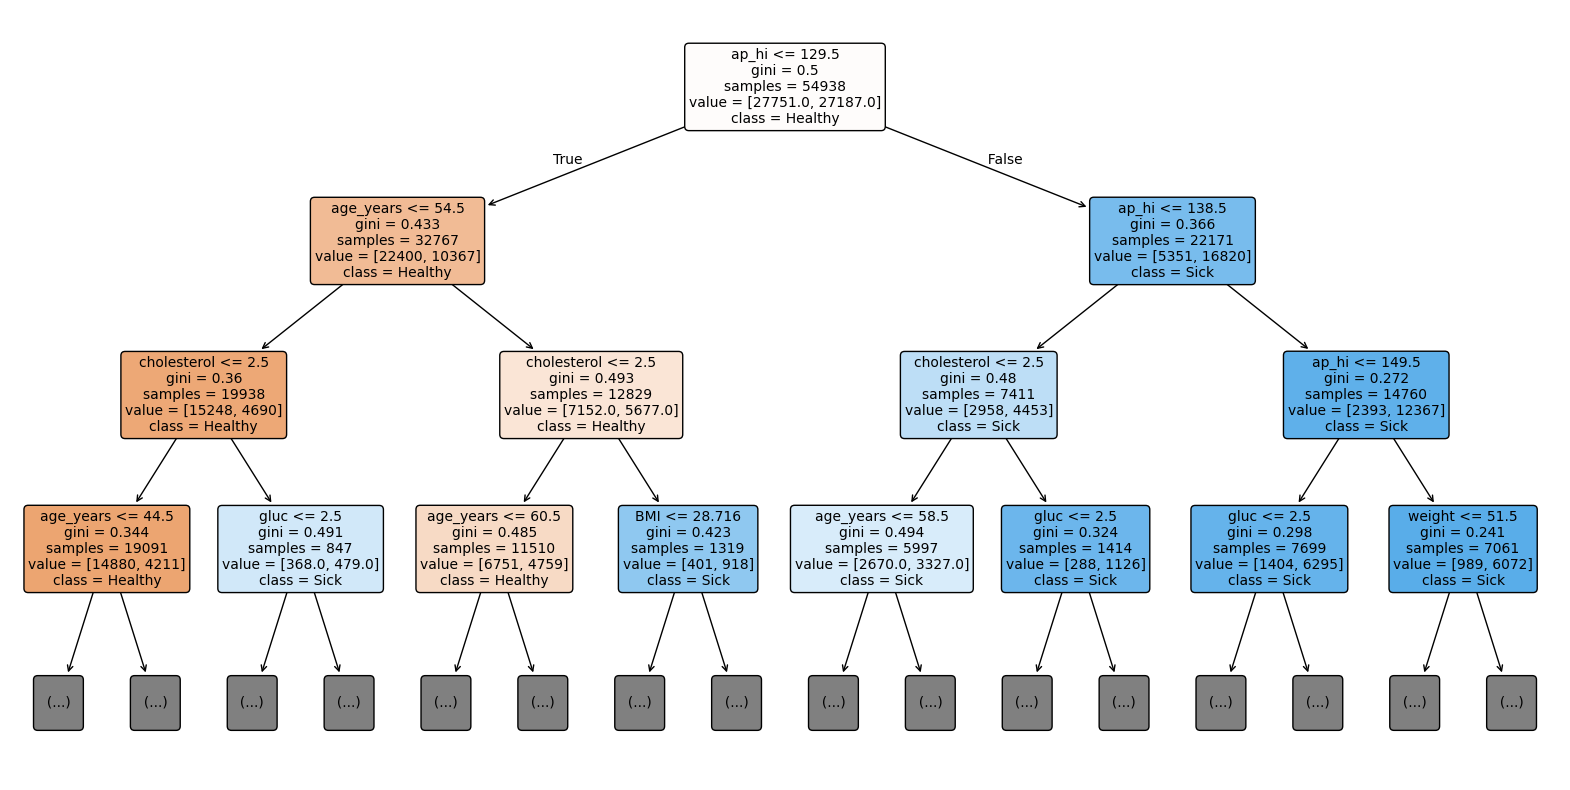

In [ ]:
plt.figure(figsize=(20,10))

plot_tree(decision_T,
          max_depth = 3,
          feature_names = X.columns,
          class_names = ['Healthy', 'Sick'],
          filled = True,
          rounded = True,
          fontsize = 10)

plt.title('Decision Tree (Top 3 Rules)')
plt.show()

**Logistic Regression**

In [ ]:
from sklearn.linear_model import LogisticRegression

In [ ]:
LR_model = LogisticRegression(random_state = 42)

In [ ]:
#train model
LR_model.fit(X_train, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression(random_state=42)

In [ ]:
# training model accuracy score
LR_train_model = accuracy_score(y_train, LR_model.predict(X_train))
print(f'Logistic Regression Training Model Accuracy Score : {LR_train_model*100:.2f}%')

#testing model accuracy score
LR_test_model = accuracy_score(y_testing, LR_model.predict(X_testing))
print(f'Logistic Regression Testing Model Accuracy Score : {LR_test_model*100:.2f}%')

Logistic Regression Training Model Accuracy Score : 72.65%
Logistic Regression Testing Model Accuracy Score : 72.53%


In [ ]:
LR_f1 = f1_score(y_testing, LR_model.predict(X_testing))

#f1_score
print(f"F1 Score: {LR_f1*100:.2f}%")

F1 Score: 70.49%


**Naive Bayes Model**

In [ ]:
from sklearn.naive_bayes import GaussianNB

In [ ]:
# train model
NB_model = GaussianNB()
NB_model.fit(X_train, y_train)

GaussianNB()

In [ ]:
# training model accuracy score
NB_train_model = accuracy_score(y_train, NB_model.predict(X_train))
print(f'Naive Bayes Training Model Accuracy Score : {NB_train_model*100:.2f}%')

#testing model accuracy score
NB_test_model = accuracy_score(y_testing, NB_model.predict(X_testing))
print(f'Naives Bayes Testing Model Accuracy Score : {NB_test_model*100:.2f}%')

Naive Bayes Training Model Accuracy Score : 70.75%
Naives Bayes Testing Model Accuracy Score : 70.76%


In [ ]:
NB_f1 = f1_score(y_testing, NB_model.predict(X_testing))

#f1_score
print(f"F1 Score: {NB_f1*100:.2f}%")

F1 Score: 66.99%


**Comparison on each model**

**Comparison Graphs**


=== FINAL SCORE ===
                 Model  Accuracy  F1-Score
0        Decision Tree     72.46     71.18
1  Logistic Regression     72.53     70.49
2        Random Forest     70.63     69.85
3          Naive Bayes     70.76     66.99


TypeError: 'str' object is not callable

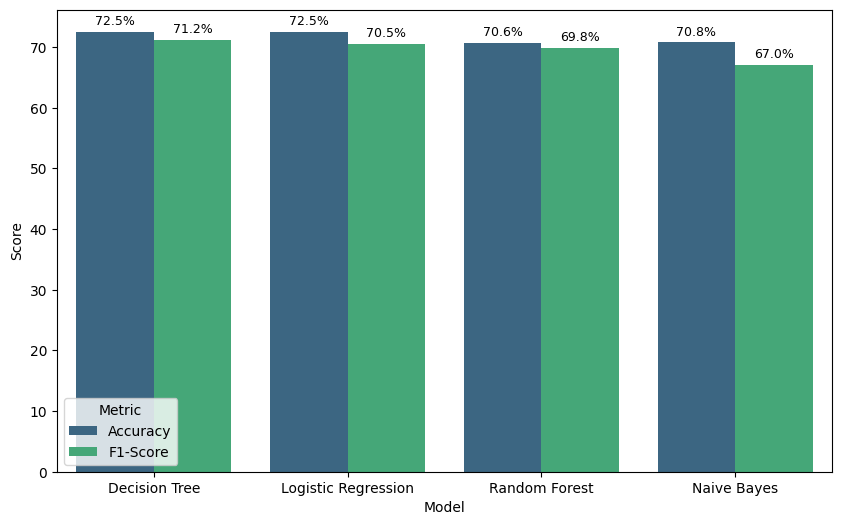

In [ ]:
#final comparison
data_final = {
    'Model': ['Decision Tree', 'Logistic Regression', 'Random Forest', 'Naive Bayes'],

    'Accuracy': [72.46, 72.53, 70.63, 70.76],

    'F1-Score': [71.18, 70.49, 69.85, 66.99]
}

# 2. Buat DataFrame
df_final = pd.DataFrame(data_final)

# Susun ikut F1-Score paling tinggi
df_final = df_final.sort_values(by='F1-Score', ascending=False)

print("\n=== FINAL SCORE ===")
print(df_final)

# GRAPH BAR ACCURACY VS F1_SCORE

df_melted = df_final.melt(id_vars="Model", var_name="Metric", value_name="Score")

plt.figure(figsize=(10, 6))

# Lukis Graf
graf = sns.barplot(x='Model', y='Score', hue='Metric', data=df_melted, palette='viridis')

# Tulis nombor atas bar
for container in graf.containers:
    graf.bar_label(container, fmt='%.1f%%', padding=3, fontsize=9)

plt.title('Accuracy vs F1-Score', fontsize=14)
plt.ylabel('Score (%)')
plt.ylim(60, 80)
plt.legend(title='Matric')
plt.show()

**Conclusion**

Based on the analysis of the four algorithms, **the Decision Tree was selected as the best one for predicting Cardiovascular disease.**
Eventhough, Logistic Regression had the highest accuracy (72.53%) than the Decision Tree (72.46%).

The main reason for **choosing the Decision Tree is it's F1-Score**. The **Decision Tree had the highest F1-Score (71.18%)** which better than Logistic Regression (70.49%). In medical problems, the **F1-Score is more important than accuracy** because it balances precision for not marking healthy people as sick and recall means not missing sic patients.  A higher **F1-Score means the model is better at correctly finding patients with heart disease while still being accurate**.

Because of this balance, the Decision Tree is the better and more reliable choice for this Cardiovascular disease prediction system.